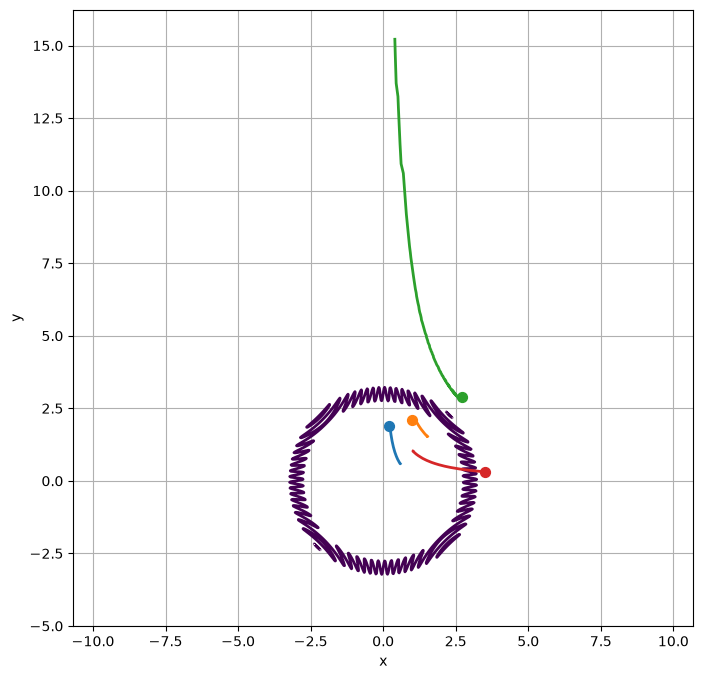

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
A = 1.4
f = 10
r = 3

# Multiple starting points
xi = [0.2, 1.0, 2.7, 3.5]
yi = [1.9, 2.1, 2.9, 0.3]

# Original curve
def F(x, y):
    return x**2 + y**2 - (A * np.sin(f*x*y) + r**2)


# Normal vector
# This is the gradient of F(x,y)
def normal_path(t, z):
    x, y = z

    nx = 2*x - (A*f*y*np.cos(f*x*y)+r**2)
    ny = 2*y - (A*f*x*np.cos(f*x*y)+r**2)

    return [nx, ny]


# Integration settings
t_span = (0, 5)
t_eval = np.linspace(t_span[0], t_span[1], 200)


# Plot original curve
x = np.linspace(-5, 5, 500)
y = np.linspace(-5, 5, 500)

X, Y = np.meshgrid(x, y)
Z = F(X, Y)

plt.figure(figsize=(8, 8))

# Original curve
plt.contour(
    X, Y, Z,
    levels=[0],
    linewidths=2
)


# Integrate a normal path for every starting point
for x0, y0 in zip(xi, yi):

    solution = solve_ivp(
        normal_path,
        t_span,
        [x0, y0],
        t_eval=t_eval
    )

    # Check integration was successful
    if solution.success:
        x_path = solution.y[0]
        y_path = solution.y[1]

        # Normal trajectory
        plt.plot(
            x_path,
            y_path,
            linewidth=2
        )

        # Starting point
        plt.scatter(
            x0,
            y0,
            s=50
        )


plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid()
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


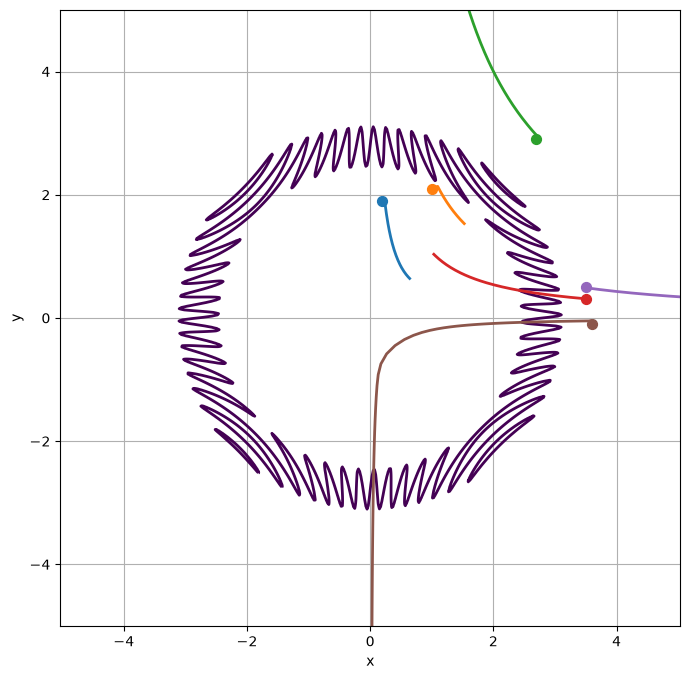

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
A = 1.8
f = 10
r = 2.8

# Multiple starting points
xi = [0.2, 1.0, 2.7, 3.5, 3.5, 3.6]
yi = [1.9, 2.1, 2.9, 0.3, 0.5, -0.1]


# Original curve
def F(x, y):
    return x**2 + y**2 - (A * np.sin(f*x*y) + r**2)


# Normal vector
def normal_path(t, z):
    x, y = z

    nx = 2*x - (A*f*y*np.cos(f*x*y) + r**2)
    ny = 2*y - (A*f*x*np.cos(f*x*y) + r**2)

    return [nx, ny]


# Stop integration if trajectory gets too far away
def stop_event(t, z):
    x, y = z

    limit = 10

    return limit**2 - (x**2 + y**2)


# Tell solve_ivp this event terminates integration
stop_event.terminal = True
stop_event.direction = -1


# Integration settings
t_span = (0, 5)
t_eval = np.linspace(0, 5, 300)


# Plot original curve
x = np.linspace(-5, 5, 500)
y = np.linspace(-5, 5, 500)

X, Y = np.meshgrid(x, y)
Z = F(X, Y)

plt.figure(figsize=(8, 8))

plt.contour(
    X, Y, Z,
    levels=[0],
    linewidths=2
)


# Integrate each normal path
for x0, y0 in zip(xi, yi):

    solution = solve_ivp(
        normal_path,
        t_span,
        [x0, y0],

        # Solver
        method="RK45",

        # Accuracy
        rtol=1e-5,
        atol=1e-7,

        # Prevent excessively large steps
        max_step=0.02,

        # Output points
        t_eval=t_eval,

        # Stop when leaving region
        events=stop_event
    )

    if solution.success or len(solution.t) > 1:

        x_path = solution.y[0]
        y_path = solution.y[1]

        plt.plot(
            x_path,
            y_path,
            linewidth=2
        )

        plt.scatter(
            x0,
            y0,
            s=50
        )


plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.grid()
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


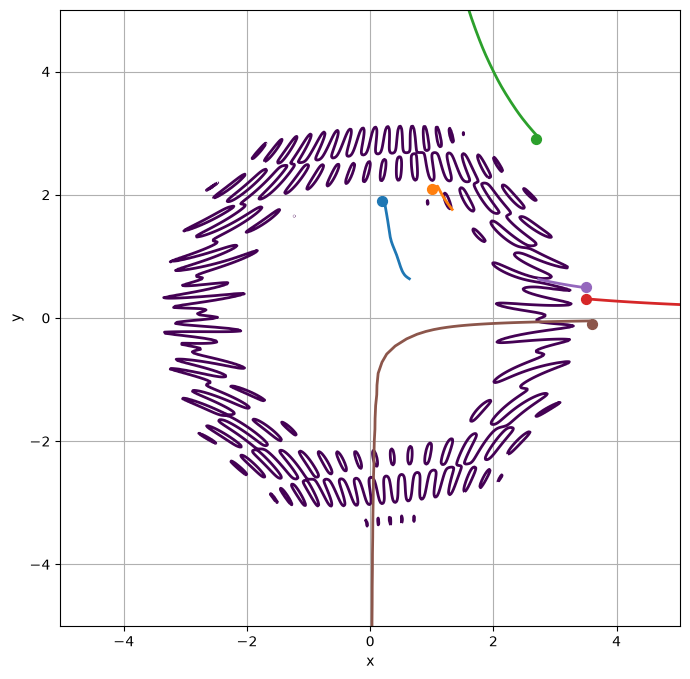

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
A = 1.8
f = 10
r = 2.8

# Multiple starting points
xi = [0.2, 1.0, 2.7, 3.5, 3.5, 3.6]
yi = [1.9, 2.1, 2.9, 0.3, 0.5, -0.1]


# Original curve
def F(x, y):
    return x**2 + y**2 - (A * np.sin(f*x*y) + r**2+A*np.cos(f*(x-1.1)*(y+0.1)))


# Normal vector
def normal_path(t, z):
    x, y = z

    nx = 2*x - (A*f*y*np.cos(f*x*y) + r**2 + A*np.sin(f*(x-1.1)*(y+0.1)))
    ny = 2*y - (A*f*x*np.cos(f*x*y) + r**2 + A*np.sin(f*(x-1.1)*(y+0.1)))

    return [nx, ny]


# Stop integration if trajectory gets too far away
def stop_event(t, z):
    x, y = z

    limit = 10

    return limit**2 - (x**2 + y**2)


# Tell solve_ivp this event terminates integration
stop_event.terminal = True
stop_event.direction = -1


# Integration settings
t_span = (0, 5)
t_eval = np.linspace(0, 5, 300)


# Plot original curve
x = np.linspace(-5, 5, 500)
y = np.linspace(-5, 5, 500)

X, Y = np.meshgrid(x, y)
Z = F(X, Y)

plt.figure(figsize=(8, 8))

plt.contour(
    X, Y, Z,
    levels=[0],
    linewidths=2
)


# Integrate each normal path
for x0, y0 in zip(xi, yi):

    solution = solve_ivp(
        normal_path,
        t_span,
        [x0, y0],

        # Solver
        method="RK45",

        # Accuracy
        rtol=1e-5,
        atol=1e-7,

        # Prevent excessively large steps
        max_step=0.02,

        # Output points
        t_eval=t_eval,

        # Stop when leaving region
        events=stop_event
    )

    if solution.success or len(solution.t) > 1:

        x_path = solution.y[0]
        y_path = solution.y[1]

        plt.plot(
            x_path,
            y_path,
            linewidth=2
        )

        plt.scatter(
            x0,
            y0,
            s=50
        )


plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.grid()
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


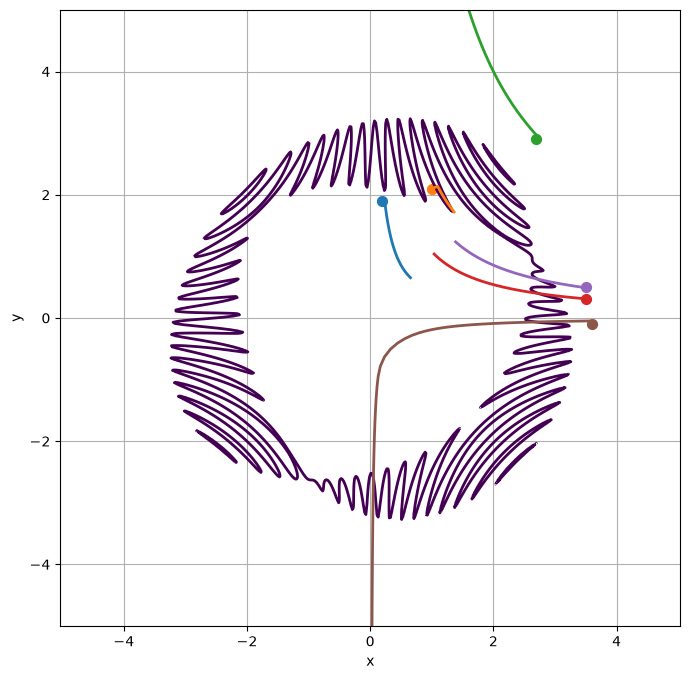

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
A = 1.8
f = 10
r = 2.8

# Multiple starting points
xi = [0.2, 1.0, 2.7, 3.5, 3.5, 3.6]
yi = [1.9, 2.1, 2.9, 0.3, 0.5, -0.1]


# Original curve
def F(x, y):
    return x**2 + y**2 - (A * np.sin(f*x*y) + r**2+A*np.cos(f*(x-0.1)*(y+0.1)))


# Normal vector
def normal_path(t, z):
    x, y = z

    nx = 2*x - (A*f*y*np.cos(f*x*y) + r**2 + A*np.sin(f*(x-0.1)*(y+0.1)))
    ny = 2*y - (A*f*x*np.cos(f*x*y) + r**2 + A*np.sin(f*(x-0.1)*(y+0.1)))

    return [nx, ny]


# Stop integration if trajectory gets too far away
def stop_event(t, z):
    x, y = z

    limit = 10

    return limit**2 - (x**2 + y**2)


# Tell solve_ivp this event terminates integration
stop_event.terminal = True
stop_event.direction = -1


# Integration settings
t_span = (0, 5)
t_eval = np.linspace(0, 5, 300)


# Plot original curve
x = np.linspace(-5, 5, 500)
y = np.linspace(-5, 5, 500)

X, Y = np.meshgrid(x, y)
Z = F(X, Y)

plt.figure(figsize=(8, 8))

plt.contour(
    X, Y, Z,
    levels=[0],
    linewidths=2
)


# Integrate each normal path
for x0, y0 in zip(xi, yi):

    solution = solve_ivp(
        normal_path,
        t_span,
        [x0, y0],

        # Solver
        method="RK45",

        # Accuracy
        rtol=1e-5,
        atol=1e-7,

        # Prevent excessively large steps
        max_step=0.02,

        # Output points
        t_eval=t_eval,

        # Stop when leaving region
        events=stop_event
    )

    if solution.success or len(solution.t) > 1:

        x_path = solution.y[0]
        y_path = solution.y[1]

        plt.plot(
            x_path,
            y_path,
            linewidth=2
        )

        plt.scatter(
            x0,
            y0,
            s=50
        )


plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.grid()
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


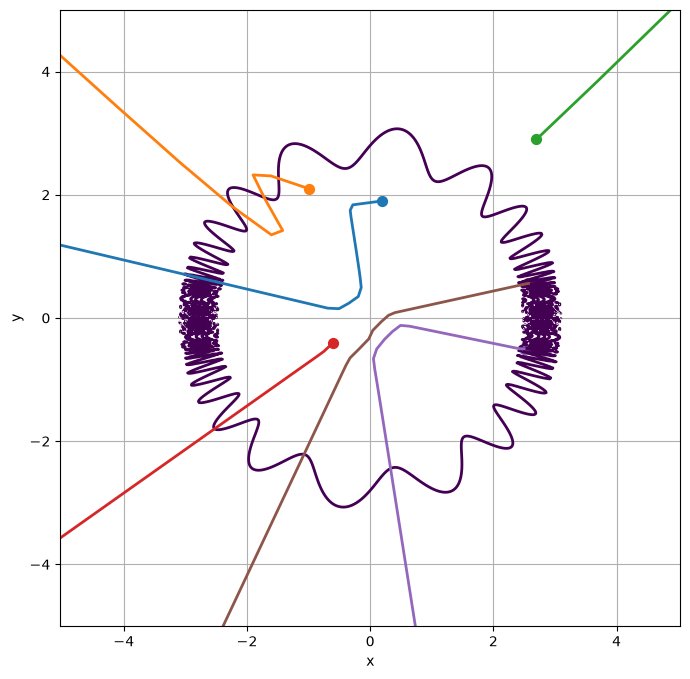

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
A = 1.8
f = 10
r = 2.8

# Multiple starting points
xi = [0.2, -1.0, 2.7, -0.6, 2.5, 2.57]
yi = [1.9, 2.1, 2.9, -0.4, -0.5, 0.56]


# Original curve
def F(x, y):
    return x**2 + y**2 - (A * np.sin(f*x/y) + r**2)


# Normal vector
def normal_path(t, z):
    x, y = z

    nx = 2*x - (A*f*y*np.cos(f*x/y) + r**2 )
    ny = 2*y - (A*f*x*np.cos(f*x/y) + r**2 )

    return [nx, ny]


# Stop integration if trajectory gets too far away
def stop_event(t, z):
    x, y = z

    limit = 10

    return limit**2 - (x**2 + y**2)


# Tell solve_ivp this event terminates integration
stop_event.terminal = True
stop_event.direction = -1


# Integration settings
t_span = (0, 5)
t_eval = np.linspace(0, 5, 300)


# Plot original curve
x = np.linspace(-5, 5, 500)
y = np.linspace(-5, 5, 500)

X, Y = np.meshgrid(x, y)
Z = F(X, Y)

plt.figure(figsize=(8, 8))

plt.contour(
    X, Y, Z,
    levels=[0],
    linewidths=2
)


# Integrate each normal path
for x0, y0 in zip(xi, yi):

    solution = solve_ivp(
        normal_path,
        t_span,
        [x0, y0],

        # Solver
        method="RK45",

        # Accuracy
        rtol=1e-5,
        atol=1e-7,

        # Prevent excessively large steps
        max_step=0.02,

        # Output points
        t_eval=t_eval,

        # Stop when leaving region
        events=stop_event
    )

    if solution.success or len(solution.t) > 1:

        x_path = solution.y[0]
        y_path = solution.y[1]

        plt.plot(
            x_path,
            y_path,
            linewidth=2
        )

        plt.scatter(
            x0,
            y0,
            s=50
        )


plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.grid()
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


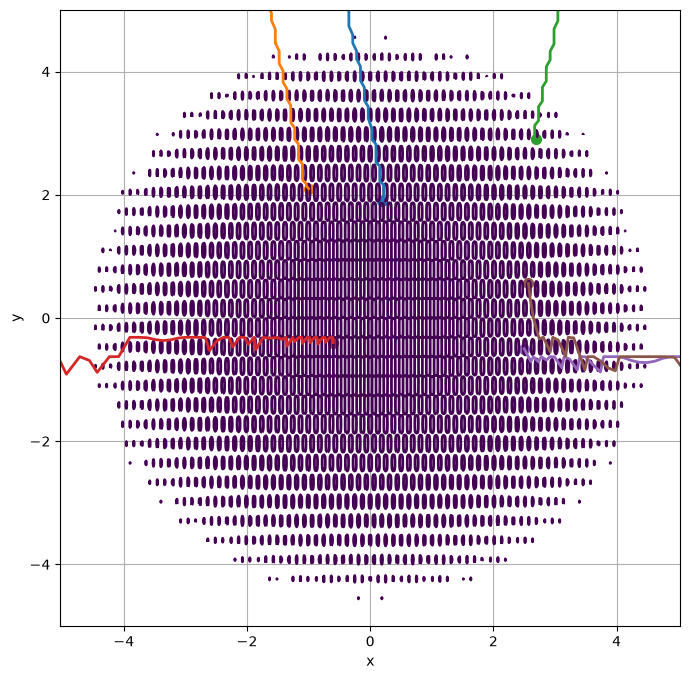

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
A = 20
f = 10
r = 1

# Multiple starting points
xi = [0.2, -1.0, 2.7, -0.6, 2.5, 2.57]
yi = [1.9, 2.1, 2.9, -0.4, -0.5, 0.56]


# Original curve
def F(x, y):
    return x**2 + y**2 - (A * np.cos(5*f*x)* np.sin(f*y) + r**2)


# Normal vector
def normal_path(t, z):
    x, y = z

    nx = 2*x - (A*f*y*np.cos(5*f*x)*np.sin(f*y) + r**2 )
    ny = 2*y - (A*f*x*np.cos(5*f*x)*np.sin(f*y) + r**2 )

    return [nx, ny]


# Stop integration if trajectory gets too far away
def stop_event(t, z):
    x, y = z

    limit = 10

    return limit**2 - (x**2 + y**2)


# Tell solve_ivp this event terminates integration
stop_event.terminal = True
stop_event.direction = -1


# Integration settings
t_span = (0, 5)
t_eval = np.linspace(0, 5, 300)


# Plot original curve
x = np.linspace(-5, 5, 500)
y = np.linspace(-5, 5, 500)

X, Y = np.meshgrid(x, y)
Z = F(X, Y)

plt.figure(figsize=(8, 8))

plt.contour(
    X, Y, Z,
    levels=[0],
    linewidths=2
)


# Integrate each normal path
for x0, y0 in zip(xi, yi):

    solution = solve_ivp(
        normal_path,
        t_span,
        [x0, y0],

        # Solver
        method="RK45",

        # Accuracy
        rtol=1e-5,
        atol=1e-7,

        # Prevent excessively large steps
        max_step=0.02,

        # Output points
        t_eval=t_eval,

        # Stop when leaving region
        events=stop_event
    )

    if solution.success or len(solution.t) > 1:

        x_path = solution.y[0]
        y_path = solution.y[1]

        plt.plot(
            x_path,
            y_path,
            linewidth=2
        )

        plt.scatter(
            x0,
            y0,
            s=50
        )


plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.grid()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
A = 20
f = 10
r = 1

# Multiple starting points
xi = [0.2, -1.0, 2.7, -0.6, 2.5, 2.57]
yi = [1.9, 2.1, 2.9, -0.4, -0.5, 0.56]


# Original curve
def F(x, y):
    return x**2 + y**2 - (A * np.cos(5*f*x)* np.sin(f*y)*np.sin(x*y) + r**2 + A * np.cos(3*f*x)*np.sin(f*y))


# Normal vector
def normal_path(t, z):
    x, y = z

    nx = 2*x - (A*f*y*np.cos(5*f*x)*np.sin(f*y)*np.sin(x*y) + r**2 + A * np.cos(3*f*x)*np.sin(f*y))
    ny = 2*y - (A*f*x*np.cos(5*f*x)*np.sin(f*y)*np.sin(x*y) + r**2 + A * np.cos(3*f*x)*np.sin(f*y))

    return [nx, ny]


# Stop integration if trajectory gets too far away
def stop_event(t, z):
    x, y = z

    limit = 10

    return limit**2 - (x**2 + y**2)


# Tell solve_ivp this event terminates integration
stop_event.terminal = True
stop_event.direction = -1


# Integration settings
t_span = (0, 20)
t_eval = np.linspace(0, 20, 300)


# Plot original curve
x = np.linspace(-5, 5, 500)
y = np.linspace(-5, 5, 500)

X, Y = np.meshgrid(x, y)
Z = F(X, Y)

plt.figure(figsize=(8, 8))

plt.contour(
    X, Y, Z,
    levels=[0],
    linewidths=2
)


# Integrate each normal path
for x0, y0 in zip(xi, yi):

    solution = solve_ivp(
        normal_path,
        t_span,
        [x0, y0],

        # Solver
        method="RK45",

        # Accuracy
        rtol=1e-5,
        atol=1e-7,

        # Prevent excessively large steps
        max_step=0.02,

        # Output points
        t_eval=t_eval,

        # Stop when leaving region
        events=stop_event
    )

    if solution.success or len(solution.t) > 1:

        x_path = solution.y[0]
        y_path = solution.y[1]

        plt.plot(
            x_path,
            y_path,
            linewidth=2
        )

        plt.scatter(
            x0,
            y0,
            s=50
        )


plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.grid()
plt.show()